Found 16516 images belonging to 15 classes.
Found 4122 images belonging to 15 classes.


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_128 (Functional)    │ (None, 4, 4, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 20480)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │       2,621,568 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 15)                  │           1,935 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,881,487 (18.62 MB)

 Trainable params: 2,623,503 (10.01 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 285s 535ms/step - accuracy: 0.6247 - loss: 1.2107 - val_accuracy: 0.8164 - val_loss: 0.5807
Epoch 2/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 297s 575ms/step - accuracy: 0.7534 - loss: 0.7684 - val_accuracy: 0.8673 - val_loss: 0.4389
Epoch 3/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 285s 552ms/step - accuracy: 0.7915 - loss: 0.6367 - val_accuracy: 0.8772 - val_loss: 0.3884
Epoch 4/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 442s 856ms/step - accuracy: 0.8119 - loss: 0.5741 - val_accuracy: 0.8777 - val_loss: 0.3762
Epoch 5/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 275s 532ms/step - accuracy: 0.8290 - loss: 0.5256 - val_accuracy: 0.8850 - val_loss: 0.3557
Epoch 6/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 279s 540ms/step - accuracy: 0.8383 - loss: 0.4962 - val_accuracy: 0.8993 - val_loss: 0.3209
Epoch 7/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 280s 541ms/step - accuracy: 0.8473 - loss: 0.4555 - val_accuracy: 0.8882 - val_loss: 0.3308
Epoch 8/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 279s 539ms/step - accuracy: 0.8511 -

Modèle sauvegardé dans plant_disease_model.h5


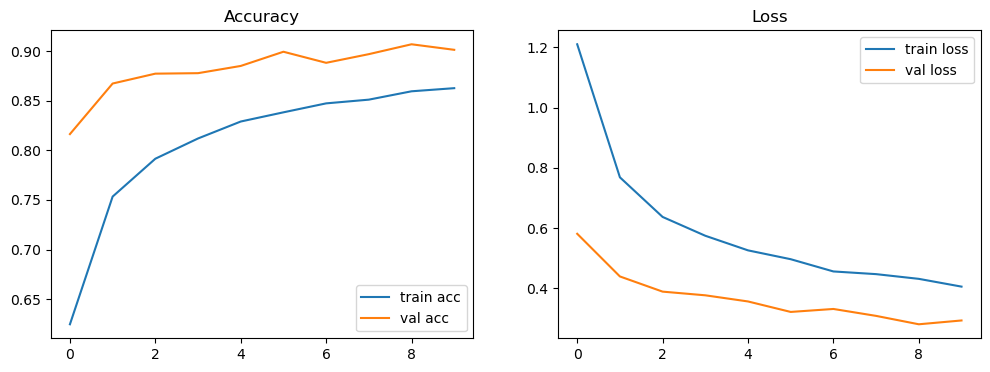

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\hp\\PlantVillage\\Tomato___Late_blight\\0001.jpg'

In [2]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.preprocessing import image
import os

# ---------------------------
#Parameters and paths
# ---------------------------
DATASET_DIR = r"C:\Users\hp\Downloads\PlantVillage" 
IMG_SIZE = (128, 128)
BATCH_SIZE = 32
EPOCHS = 10   
MODEL_PATH = 'plant_disease_model.h5'

# ---------------------------
#Pretreatment and augmentation
# ---------------------------
datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2  # 20% images for validation
)

#Train generator
train_generator = datagen.flow_from_directory(
    DATASET_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

# Validation generator
val_generator = datagen.flow_from_directory(
    DATASET_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

# ---------------------------
#Model creation CNN (MobileNetV2)
# ---------------------------
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(128,128,3))
base_model.trainable = False  # freeze the pre-trained model

model = Sequential([
    base_model,
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(train_generator.num_classes, activation='softmax')
])

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# ---------------------------
#Training
# ---------------------------
history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator
)

# ---------------------------
#Save the model
# ---------------------------
model.save(MODEL_PATH)
print(f"Modèle sauvegardé dans {MODEL_PATH}")

# ---------------------------
#Graphics accuracy/loss
# ---------------------------
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.title('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.title('Loss')
plt.legend()
plt.show()

# ---------------------------
#Function for test
# ---------------------------
def predict_leaf(img_path):
    img = image.load_img(img_path, target_size=IMG_SIZE)
    img_array = image.img_to_array(img)/255.0
    img_array = np.expand_dims(img_array, axis=0)
    
    pred = model.predict(img_array)
    class_idx = np.argmax(pred)
    class_label = list(train_generator.class_indices.keys())[class_idx]
    print(f"Prediction: {class_label}")

In [12]:
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
import numpy as np

model = load_model('plant_disease_model.h5')

def predict_leaf(img_path):
    img = image.load_img(img_path, target_size=(128,128))
    img_array = image.img_to_array(img)/255.0
    img_array = np.expand_dims(img_array, axis=0)
    
    pred = model.predict(img_array)
    class_idx = np.argmax(pred)
    class_label = list(train_generator.class_indices.keys())[class_idx]
    print(f"Prediction: {class_label}")

# Exemple
test_image_path = r"C:\Users\hp\Downloads\PlantVillage\Tomato_healthy\image02.jpg"

predict_leaf(test_image_path)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Prediction: Tomato_healthy


129/129 ━━━━━━━━━━━━━━━━━━━━ 53s 394ms/step


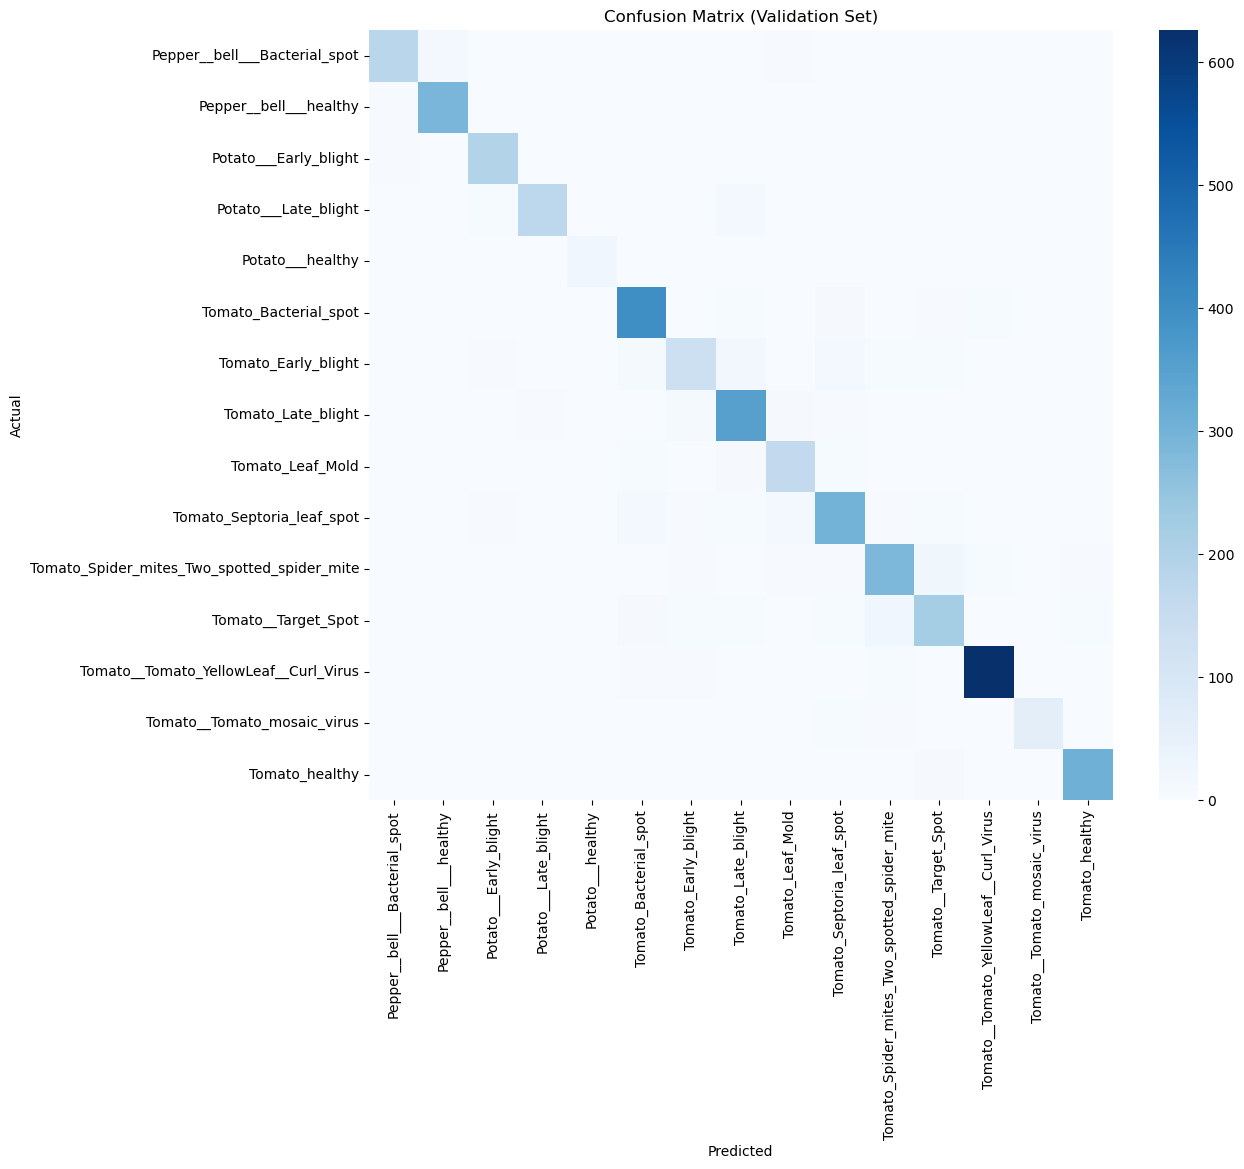

                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot       0.95      0.90      0.93       199
                     Pepper__bell___healthy       0.93      0.98      0.96       295
                      Potato___Early_blight       0.93      0.97      0.95       200
                       Potato___Late_blight       0.95      0.88      0.91       200
                           Potato___healthy       1.00      0.80      0.89        30
                      Tomato_Bacterial_spot       0.90      0.94      0.92       425
                        Tomato_Early_blight       0.81      0.67      0.73       200
                         Tomato_Late_blight       0.85      0.92      0.88       381
                           Tomato_Leaf_Mold       0.82      0.87      0.84       190
                  Tomato_Septoria_leaf_spot       0.86      0.85      0.85       354
Tomato_Spider_mites_Two_spotted_spider_mite       0.86      0.85

In [13]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Retrieve the actual labels
true_labels = val_generator.classes

# Prediction
pred_probs = model.predict(val_generator)
pred_labels = np.argmax(pred_probs, axis=1)

# Class names in the correct order
class_names = list(val_generator.class_indices.keys())

#Confusion Matrix
cm = confusion_matrix(true_labels, pred_labels)

# Display
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=False, cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Validation Set)")
plt.show()

# Classification report
print(classification_report(true_labels, pred_labels, target_names=class_names))


In [18]:
import cv2
import numpy as np
from tensorflow.keras.models import load_model

# Charger le modèle
model = load_model(r"plant_disease_model.h5")

# Classes (met EXACTEMENT les classes dans l'ordre utilisé à l'entraînement)
classes = [
    "Pepper__bell___Bacterial_spot",
    "Pepper__bell___healthy",
    "Potato___Early_blight",
    "Potato___Late_blight",
    "Potato___healthy",
    "Tomato_Bacterial_spot",
    "Tomato_Early_blight",
    "Tomato_Late_blight",
    "Tomato_Leaf_Mold",
    "Tomato_Septoria_leaf_spot",
    "Tomato_Spider_mites_Two_spotted_spider_mite",
    "Tomato_Target_Spot",
    "Tomato_Tomato_Yellow_Leaf_Curl_Virus",
    "Tomato_mosaic_virus",
    "Tomato_healthy"
]

# Taille utilisée à l'entraînement
IMG_SIZE = 128  # change si tu as utilisé 224x224 ou autre

# Ouvrir la caméra
cap = cv2.VideoCapture(0)

if not cap.isOpened():
    raise Exception("La caméra refuse de s’ouvrir. Comme d’hab.")

print("Démarrage du streaming... Appuie sur Q pour quitter.")

while True:
    ret, frame = cap.read()
    if not ret:
        print("Impossible de lire la frame. Sérieux…")
        break

    # Prétraitement de l'image
    img = cv2.resize(frame, (IMG_SIZE, IMG_SIZE))
    img = img.astype("float32") / 255.0
    img = np.expand_dims(img, axis=0)

    # Prédiction
    preds = model.predict(img)
    class_index = np.argmax(preds)
    class_name = classes[class_index]
    confidence = preds[0][class_index]

    # Ajouter le texte sur l'image
    text = f"{class_name} ({confidence*100:.1f}%)"
    cv2.putText(frame, text, (10, 30), cv2.FONT_HERSHEY_SIMPLEX,
                0.7, (0, 255, 0), 2)

    # Afficher la frame
    cv2.imshow("Plant Disease Detection - Real Time", frame)

    # Exit
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

Exception: La caméra refuse de s’ouvrir. Comme d’hab.